In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

# Utility: Overlay mask on image (grayscale or RGB)
def overlay_mask_rgb(img, mask, alpha=0.4, color=(1, 0, 0)):
    if len(img.shape) == 2:  # Grayscale
        img_rgb = np.stack([img] * 3, axis=-1) / 255.0
    elif len(img.shape) == 3 and img.shape[0] == 3:
        # Tensor image format: [C, H, W]
        img_rgb = img.transpose(1, 2, 0) / 255.0
    elif len(img.shape) == 3 and img.shape[-1] == 3:
        img_rgb = img / 255.0
    else:
        raise ValueError("Unsupported image shape:", img.shape)

    overlay = img_rgb.copy()
    overlay[mask == 1] = (1 - alpha) * overlay[mask == 1] + alpha * np.array(color)
    return overlay

In [36]:
# ------------------------------
# Change this to point to result
# ------------------------------
result_file = "/home/iiitb/Desktop/anant/GridRaster/test_outputs/result_11.pt"  # Change index as needed

# Load the .pt file
result = torch.load(result_file)

img = result['image']
segments = result['segments']
gt_mask = result['gt_mask']
pred_mask = result['pred_mask']

# Convert to numpy (if not already)
if torch.is_tensor(img): img = img.numpy()
if torch.is_tensor(segments): segments = segments.numpy()
if torch.is_tensor(gt_mask): gt_mask = gt_mask.numpy()
if torch.is_tensor(pred_mask): pred_mask = pred_mask.numpy()

In [25]:
for var in [gt_mask, pred_mask]:
    res, count = np.unique(var, return_counts=True)
    print(f"Unique values in {var} is: {res} and teh count is: {count}")


Unique values in [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] is: [0 1] and teh count is: [49592   584]
Unique values in [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] is: [0 1] and teh count is: [48531  1645]


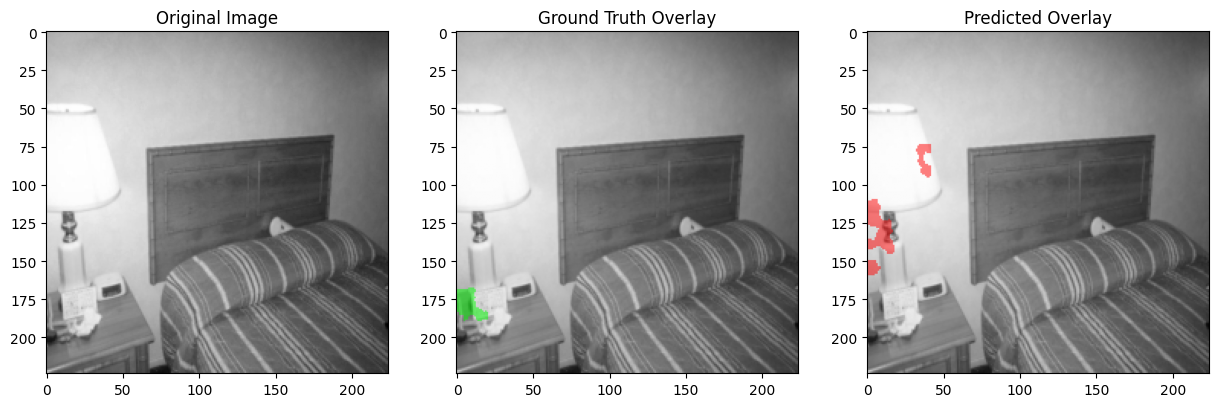

In [37]:
# ------------------------------
# Show results
# ------------------------------
plt.figure(figsize=(15, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.title("Original Image")
if img.ndim == 2:
    plt.imshow(img, cmap='gray')
else:
    plt.imshow(img.transpose(1, 2, 0).astype(np.uint8))  # [C,H,W] → [H,W,C]

# Ground Truth
plt.subplot(1, 3, 2)
plt.title("Ground Truth Overlay")
overlay_gt = overlay_mask_rgb(img, gt_mask, alpha=0.5, color=(0, 1, 0))
plt.imshow(overlay_gt)

# Prediction
plt.subplot(1, 3, 3)
plt.title("Predicted Overlay")
overlay_pred = overlay_mask_rgb(img, pred_mask, alpha=0.5, color=(1, 0, 0))
plt.imshow(overlay_pred)

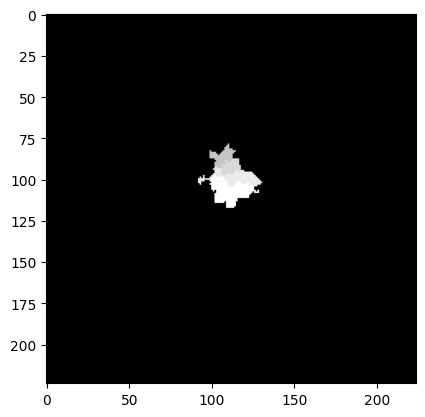

In [22]:
plt.imshow(segments, cmap="gray")

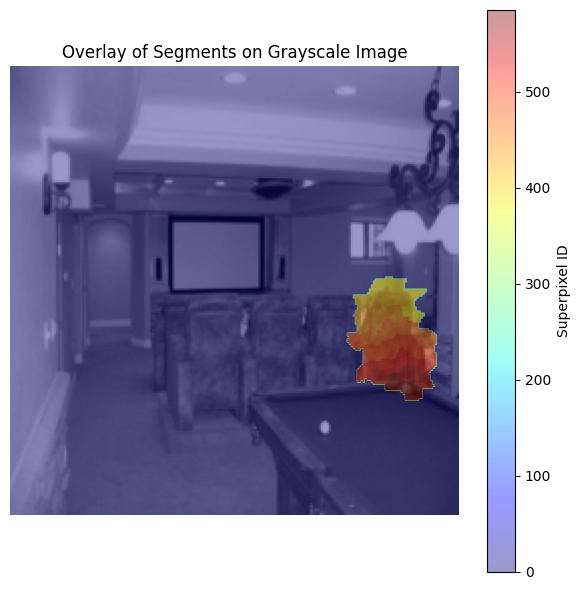

In [27]:
# Plotting
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')  # show grayscale image
plt.imshow(segments, cmap='jet', alpha=0.4)  # overlay segments in color
plt.colorbar(label="Superpixel ID")
plt.title("Overlay of Segments on Grayscale Image")
plt.axis("off")
plt.tight_layout()
plt.show()